# 07. Análisis de sentimiento textual con roles proxy

Este notebook aplica análisis de sentimiento sobre la transcripción automática generada por Whisper.  
El análisis se realiza **sobre el texto transcrito**, pero utilizando las etiquetas de rol construidas en el Notebook 06 (`AGENT` / `CLIENT`) para poder agregar resultados por interlocutor.

Importante: este notebook corresponde a la capa **textual** del análisis. No sustituye un análisis acústico/prosódico sin transcripción, sino que lo complementa.

Entradas principales:

- `data/transcription_outputs/06_transcribed_segments_final.csv` o `all_segments_transcribed.csv`
- `data/proxy_groundtruth_outputs/segment_level_proxy_groundtruth.csv`

Salidas principales:

- sentimiento por segmento;
- sentimiento por llamada;
- sentimiento por rol (`AGENT` / `CLIENT`);
- evolución temporal del sentimiento por fase de llamada;
- resumen final para memoria y presentación.

In [1]:
# ============================================================
# CELDA 1 - INSTALACIÓN OPCIONAL
# ============================================================

# Ejecutar solo si el entorno no tiene transformers instalado.
# En la VM puede dejarse comentado si ya está instalado.

INSTALL_DEPENDENCIES = False

if INSTALL_DEPENDENCIES:
    %pip install -q transformers accelerate

In [2]:
# ============================================================
# CELDA 2 - IMPORTS
# ============================================================

from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

import torch
from transformers import pipeline

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

In [3]:
# ============================================================
# CELDA 3 - CONFIGURACIÓN DE RUTAS Y PARÁMETROS
# ============================================================

PROJECT_DIR = Path("/home/jupyter/TFM_ProcesadoDeAudios")

TRANSCRIPTION_DIR = PROJECT_DIR / "data" / "transcription_outputs"
PROXY_DIR = PROJECT_DIR / "data" / "proxy_groundtruth_outputs"
SENTIMENT_DIR = PROJECT_DIR / "data" / "sentiment_outputs"
FIGURES_DIR = SENTIMENT_DIR / "figures"

SENTIMENT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Entradas posibles de transcripción Whisper.
TRANSCRIPTION_CANDIDATES = [
    TRANSCRIPTION_DIR / "06_transcribed_segments_final.csv",
    TRANSCRIPTION_DIR / "all_segments_transcribed.csv",
    TRANSCRIPTION_DIR / "transcribed_segments_final.csv",
]

# Entrada principal del Notebook 06.
PROXY_SEGMENT_CSV = PROXY_DIR / "segment_level_proxy_groundtruth.csv"

# Salidas.
SEGMENTS_WITH_SENTIMENT_CSV = SENTIMENT_DIR / "segments_with_sentiment_textual.csv"
ALL_SEGMENTS_ENRICHED_CSV = SENTIMENT_DIR / "all_segments_sentiment_textual_enriched.csv"
CALL_SENTIMENT_CSV = SENTIMENT_DIR / "call_level_sentiment_textual.csv"
CALL_ROLE_SENTIMENT_CSV = SENTIMENT_DIR / "call_role_level_sentiment_textual.csv"
ROLE_SENTIMENT_CSV = SENTIMENT_DIR / "role_level_sentiment_textual.csv"
SPEAKER_SENTIMENT_CSV = SENTIMENT_DIR / "speaker_level_sentiment_textual.csv"
TEMPORAL_SENTIMENT_CSV = SENTIMENT_DIR / "temporal_sentiment_textual.csv"
SENTIMENT_SUMMARY_CSV = SENTIMENT_DIR / "sentiment_textual_summary_for_memory.csv"
CHECKPOINT_SENTIMENT_CSV = SENTIMENT_DIR / "sentiment_segments_checkpoint.csv"

# Modelo textual.
MODEL_NAME = "pysentimiento/robertuito-sentiment-analysis"

# Filtros mínimos para enviar segmentos al modelo.
MIN_WORDS_FOR_SENTIMENT = 2
BATCH_SIZE_GPU = 32
BATCH_SIZE_CPU = 8

print("PROJECT_DIR:", PROJECT_DIR)
print("TRANSCRIPTION_DIR:", TRANSCRIPTION_DIR)
print("PROXY_DIR:", PROXY_DIR)
print("SENTIMENT_DIR:", SENTIMENT_DIR)
print("PROXY_SEGMENT_CSV:", PROXY_SEGMENT_CSV, "→", "OK" if PROXY_SEGMENT_CSV.exists() else "NO EXISTE")

print("Candidatos de transcripción:")
for p in TRANSCRIPTION_CANDIDATES:
    print("-", p.name, "→", "OK" if p.exists() else "NO EXISTE")

PROJECT_DIR: /home/jupyter/TFM_ProcesadoDeAudios
TRANSCRIPTION_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/transcription_outputs
PROXY_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs
SENTIMENT_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/sentiment_outputs
PROXY_SEGMENT_CSV: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/segment_level_proxy_groundtruth.csv → OK
Candidatos de transcripción:
- 06_transcribed_segments_final.csv → OK
- all_segments_transcribed.csv → OK
- transcribed_segments_final.csv → NO EXISTE


In [4]:
# ============================================================
# CELDA 4 - FUNCIONES AUXILIARES
# ============================================================

def first_existing_path(paths):
    """Devuelve el primer path existente dentro de una lista."""
    for p in paths:
        if p.exists():
            return p
    return None


def detect_text_col(df):
    """Detecta la columna de texto Whisper, no la transcripción oficial."""
    candidates = [
        "text",
        "text_clean",
        "whisper_text",
        "transcription_text",
        "transcribed_text",
        "segment_text",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"No se encontró columna de texto. Columnas disponibles: {list(df.columns)}")


def normalize_audio_name(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = s.replace(".wav", "")
    return s


def add_join_keys(df):
    """Crea llaves robustas para unir transcripción Whisper y proxy por segmento."""
    out = df.copy()
    if "audio_stem" in out.columns:
        out["_join_audio"] = out["audio_stem"].map(normalize_audio_name)
    elif "audio_file" in out.columns:
        out["_join_audio"] = out["audio_file"].map(normalize_audio_name)
    else:
        raise ValueError("No hay audio_stem ni audio_file para construir llave de unión.")

    if "segment_id_raw" in out.columns:
        out["_join_segment_id"] = out["segment_id_raw"].astype(str)
    else:
        out["_join_segment_id"] = ""

    for col in ["start", "end"]:
        if col in out.columns:
            out[f"_join_{col}"] = pd.to_numeric(out[col], errors="coerce").round(3)
        else:
            out[f"_join_{col}"] = np.nan

    if "speaker_final" in out.columns:
        out["_join_speaker_final"] = out["speaker_final"].astype(str)
    elif "speaker" in out.columns:
        out["_join_speaker_final"] = out["speaker"].astype(str)
    else:
        out["_join_speaker_final"] = ""

    return out


def choose_role_col(df):
    """Detecta columna de rol proxy creada por Notebook 06."""
    candidates = [
        "official_role_proxy",
        "role_proxy",
        "assigned_role",
        "probable_role",
        "role",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def normalize_role(value):
    if pd.isna(value):
        return "UNKNOWN"
    v = str(value).strip().upper()
    if v in ["AGENT", "CLIENT"]:
        return v
    return "UNKNOWN"


def normalize_sentiment_label(label):
    """Normaliza etiquetas del modelo a negative / neutral / positive."""
    if pd.isna(label):
        return np.nan
    value = str(label).strip().lower()

    mapping = {
        "neg": "negative",
        "negative": "negative",
        "label_0": "negative",
        "neu": "neutral",
        "neutral": "neutral",
        "label_1": "neutral",
        "pos": "positive",
        "positive": "positive",
        "label_2": "positive",
    }
    return mapping.get(value, value)


def sentiment_to_numeric(label):
    mapping = {
        "negative": -1,
        "neutral": 0,
        "positive": 1,
    }
    return mapping.get(label, np.nan)


def seconds_to_mmss(x):
    if pd.isna(x):
        return ""
    x = float(x)
    minutes = int(x // 60)
    seconds = int(round(x % 60))
    return f"{minutes:02d}:{seconds:02d}"


def add_time_interval(df):
    out = df.copy()
    if {"start", "end"}.issubset(out.columns):
        out["interval_mmss"] = out.apply(
            lambda r: f"{seconds_to_mmss(r['start'])} - {seconds_to_mmss(r['end'])}",
            axis=1,
        )
    return out


def safe_pct(series, condition):
    if len(series) == 0:
        return np.nan
    return float(condition(series).mean())

In [5]:
# ============================================================
# CELDA 5 - CARGA DE TRANSCRIPCIÓN WHISPER + ROLES PROXY
# ============================================================

transcription_path = first_existing_path(TRANSCRIPTION_CANDIDATES)

if transcription_path is None:
    raise FileNotFoundError(
        "No se encontró ningún CSV de transcripción Whisper. Revisa TRANSCRIPTION_CANDIDATES."
    )

print("Transcripción Whisper seleccionada:", transcription_path)
df_transcribed = pd.read_csv(transcription_path)
print("df_transcribed:", df_transcribed.shape)

text_col = detect_text_col(df_transcribed)
print("Columna de texto Whisper:", text_col)

df_transcribed = df_transcribed.copy()
df_transcribed["text_whisper"] = df_transcribed[text_col].fillna("").astype(str).str.strip()

# Si existe proxy segment-level, se usa para incorporar AGENT / CLIENT.
if PROXY_SEGMENT_CSV.exists():
    df_proxy = pd.read_csv(PROXY_SEGMENT_CSV)
    print("df_proxy:", df_proxy.shape)

    role_col = choose_role_col(df_proxy)
    print("Columna de rol detectada en proxy:", role_col)

    if role_col is not None:
        df_proxy = df_proxy.copy()
        df_proxy["role_proxy"] = df_proxy[role_col].map(normalize_role)
    else:
        df_proxy = df_proxy.copy()
        df_proxy["role_proxy"] = "UNKNOWN"

    # Mantener solo columnas de proxy que interesan.
    proxy_keep_cols = [
        c for c in [
            "audio_file", "audio_stem", "segment_id_raw", "start", "end", "speaker_final",
            "role_proxy", "probable_role", "official_role_proxy", "role_confidence",
            "proxy_confidence", "proxy_method", "role_mapping_status", "n_matches_total"
        ] if c in df_proxy.columns
    ]

    df_t_join = add_join_keys(df_transcribed)
    df_p_join = add_join_keys(df_proxy[proxy_keep_cols])

    join_cols = ["_join_audio", "_join_segment_id", "_join_start", "_join_end", "_join_speaker_final"]

    # Evitar duplicados en proxy por si hay varias filas con la misma llave.
    df_p_join = df_p_join.drop_duplicates(subset=join_cols)

    df_base = df_t_join.merge(
        df_p_join[[*join_cols, *[c for c in proxy_keep_cols if c not in df_transcribed.columns or c in ["role_proxy", "probable_role", "official_role_proxy", "role_confidence", "proxy_confidence", "proxy_method", "role_mapping_status", "n_matches_total"]]]],
        on=join_cols,
        how="left",
        suffixes=("", "_proxy")
    )

    if "role_proxy" not in df_base.columns:
        df_base["role_proxy"] = "UNKNOWN"
    df_base["role_proxy"] = df_base["role_proxy"].map(normalize_role)

else:
    print("No existe segment_level_proxy_groundtruth.csv. Se continuará sin roles proxy.")
    df_base = df_transcribed.copy()
    df_base["role_proxy"] = "UNKNOWN"

# Limpieza básica.
df_base["text_whisper"] = df_base["text_whisper"].fillna("").astype(str).str.strip()
df_base["n_chars"] = df_base["text_whisper"].str.len()
df_base["n_words"] = df_base["text_whisper"].apply(lambda x: len(x.split()) if x else 0)

if "audio_stem" not in df_base.columns and "audio_file" in df_base.columns:
    df_base["audio_stem"] = df_base["audio_file"].map(normalize_audio_name)

if "audio_file" not in df_base.columns and "audio_stem" in df_base.columns:
    df_base["audio_file"] = df_base["audio_stem"].astype(str) + ".wav"

if "speaker_final" not in df_base.columns and "speaker" in df_base.columns:
    df_base["speaker_final"] = df_base["speaker"]

# ID estable para checkpoint y merge posterior.
df_base = add_time_interval(df_base)
df_base["sentiment_uid"] = (
    df_base["audio_stem"].astype(str) + "__" +
    df_base.get("segment_id_raw", pd.Series(range(len(df_base)), index=df_base.index)).astype(str) + "__" +
    pd.to_numeric(df_base.get("start", np.nan), errors="coerce").round(3).astype(str) + "__" +
    pd.to_numeric(df_base.get("end", np.nan), errors="coerce").round(3).astype(str) + "__" +
    df_base.get("speaker_final", "").astype(str)
)

print("Resumen base:")
print("Audios:", df_base["audio_file"].nunique())
print("Segmentos:", len(df_base))
print("Segmentos con texto:", int((df_base["n_chars"] > 0).sum()))
print("Segmentos con rol AGENT/CLIENT:", int(df_base["role_proxy"].isin(["AGENT", "CLIENT"]).sum()))

role_counts = df_base["role_proxy"].value_counts(dropna=False)
display(role_counts.to_frame("n_segments"))

display(
    df_base[[c for c in ["audio_file", "interval_mmss", "speaker_final", "role_proxy", "text_whisper", "n_words"] if c in df_base.columns]]
    .head(10)
)

Transcripción Whisper seleccionada: /home/jupyter/TFM_ProcesadoDeAudios/data/transcription_outputs/06_transcribed_segments_final.csv
df_transcribed: (40352, 55)
Columna de texto Whisper: text
df_proxy: (40352, 49)
Columna de rol detectada en proxy: official_role_proxy
Resumen base:
Audios: 1181
Segmentos: 40352
Segmentos con texto: 38872
Segmentos con rol AGENT/CLIENT: 39868


,n_segments
role_proxy,
AGENT,20672
CLIENT,19196
UNKNOWN,484


,audio_file,interval_mmss,speaker_final,role_proxy,text_whisper,n_words
0,raw_9154117451310006851_clean.wav,00:00 - 00:04,SPEAKER_01,AGENT,"Hola, buenos días. Pregunto por Luis Ángel. Soy Nayara del departamento técnico de Oran.",14
1,raw_9154117451310006851_clean.wav,00:05 - 00:06,SPEAKER_00,CLIENT,"Sí, cuéntame.",2
2,raw_9154117451310006851_clean.wav,00:06 - 00:14,SPEAKER_01,AGENT,"Hola Luis, me encanta saludarte. El motivo de mi llamada es porque estamos haciendo seguimientos sobre el estado de tu incidencia y la estoy reclamando ahor...",28
3,raw_9154117451310006851_clean.wav,00:14 - 00:15,SPEAKER_00,CLIENT,¿Te,1
4,raw_9154117451310006851_clean.wav,00:15 - 00:20,SPEAKER_01,AGENT,han llamado los técnicos de plantas terna o algo o no tienes noticias?,13
5,raw_9154117451310006851_clean.wav,00:20 - 00:22,SPEAKER_00,CLIENT,"O sea, ahora tenemos internet.",5
6,raw_9154117451310006851_clean.wav,00:23 - 00:24,SPEAKER_01,AGENT,¿Ahora tienes internet?,3
7,raw_9154117451310006851_clean.wav,00:25 - 00:26,SPEAKER_01,AGENT,"Vale, pues",2
8,raw_9154117451310006851_clean.wav,00:26 - 00:30,SPEAKER_00,CLIENT,"lo he estado reclamándonos. El viernes por la tarde, más o menos.",12
9,raw_9154117451310006851_clean.wav,00:31 - 00:33,SPEAKER_01,AGENT,Pues es que no nos habían dicho nada.,8


In [6]:
# ============================================================
# CELDA 6 - CONTROL DE CALIDAD PREVIO
# ============================================================

quality_summary = pd.DataFrame([
    {
        "metric": "audios_total",
        "value": df_base["audio_file"].nunique(),
    },
    {
        "metric": "segments_total",
        "value": len(df_base),
    },
    {
        "metric": "segments_with_text",
        "value": int((df_base["n_chars"] > 0).sum()),
    },
    {
        "metric": "segments_without_text",
        "value": int((df_base["n_chars"] == 0).sum()),
    },
    {
        "metric": "segments_with_role_proxy",
        "value": int(df_base["role_proxy"].isin(["AGENT", "CLIENT"]).sum()),
    },
    {
        "metric": "avg_words_per_segment",
        "value": round(df_base["n_words"].mean(), 2),
    },
    {
        "metric": "median_words_per_segment",
        "value": round(df_base["n_words"].median(), 2),
    },
])

display(quality_summary)

# Dataset que sí se enviará al modelo.
df_sent_input = df_base[
    (df_base["text_whisper"].notna()) &
    (df_base["text_whisper"].astype(str).str.strip() != "") &
    (df_base["n_words"] >= MIN_WORDS_FOR_SENTIMENT)
].copy().reset_index(drop=True)

print("Segmentos disponibles:", len(df_base))
print("Segmentos enviados a sentimiento:", len(df_sent_input))
print("Audios con segmentos enviados:", df_sent_input["audio_file"].nunique())

display(
    df_sent_input[[c for c in ["audio_file", "interval_mmss", "speaker_final", "role_proxy", "n_words", "text_whisper"] if c in df_sent_input.columns]]
    .sample(min(10, len(df_sent_input)), random_state=42)
)

,metric,value
0,audios_total,1181.00
1,segments_total,40352.00
2,segments_with_text,38872.00
3,segments_without_text,1480.00
4,segments_with_role_proxy,39868.00
5,avg_words_per_segment,12.73
6,median_words_per_segment,9.00


Segmentos disponibles: 40352
Segmentos enviados a sentimiento: 36453
Audios con segmentos enviados: 1181


,audio_file,interval_mmss,speaker_final,role_proxy,n_words,text_whisper
13075,raw_bajas_9156492057710006851_clean.wav,01:19 - 01:21,SPEAKER_01,CLIENT,6,"perdón, disculpa. ¿Qué número es completo?"
23856,raw_bajas_9157044753870006851_clean.wav,01:30 - 01:36,SPEAKER_00,AGENT,10,"Vale. Cristian, ¿tienes actualmente el pack siniseries con dos líneas"
1682,raw_9154817984460016851_clean.wav,00:01 - 00:04,SPEAKER_00,AGENT,13,"Bienvenida, Onans. Mi nombre es Fernando de Sevilla. ¿En qué le puedo ayudar?"
20987,raw_9156884044230006851_clean.wav,01:30 - 01:31,SPEAKER_00,AGENT,6,"Bien, bien, bien. Bien, bien, bien."
27144,raw_bajas_9157209679850016851_clean.wav,00:13 - 00:20,SPEAKER_01,CLIENT,22,"Hola, mira que voy a tener un cambio de signo y me gustaría quitar todo lo que es el internet, las líneas,"
33634,raw_bajas_9157364870320006851_clean.wav,01:48 - 01:49,SPEAKER_00,AGENT,5,"Sí, pero acaban 67. No"
25688,raw_bajas_9157132783720006851_clean.wav,02:49 - 02:51,SPEAKER_00,CLIENT,7,"Vale, muchísimas gracias. Hasta ahora, un saludo."
35584,raw_bajas_9157417906270006851_clean.wav,03:14 - 03:15,SPEAKER_01,AGENT,4,¿Vayas a colar? 311.
28585,raw_bajas_9157243110910026851_clean.wav,03:25 - 03:28,SPEAKER_01,CLIENT,11,Que apenas finalizamos esta llamada... Es que me tengo que marchar...
28458,raw_bajas_9157238239120016851_clean.wav,01:54 - 01:55,SPEAKER_00,CLIENT,2,Número 6.


In [7]:
# ============================================================
# CELDA 7 - CARGAR MODELO DE SENTIMIENTO TEXTUAL
# ============================================================

DEVICE = 0 if torch.cuda.is_available() else -1
BATCH_SIZE = BATCH_SIZE_GPU if torch.cuda.is_available() else BATCH_SIZE_CPU

print("Modelo:", MODEL_NAME)
print("Device:", "cuda" if DEVICE == 0 else "cpu")
print("Batch size:", BATCH_SIZE)

sentiment_pipeline = pipeline(
    task="sentiment-analysis",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=DEVICE,
)

print("Modelo cargado correctamente.")

Modelo: pysentimiento/robertuito-sentiment-analysis
Device: cpu
Batch size: 8


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Modelo cargado correctamente.


In [8]:
# ============================================================
# CELDA 8 - PRUEBA RÁPIDA DEL MODELO
# ============================================================

test_texts = [
    "Estoy muy enfadada porque llevo esperando mucho tiempo.",
    "Muchas gracias, me has ayudado mucho.",
    "De acuerdo, gracias.",
    "No entiendo por qué me han cobrado esto."
]

sentiment_pipeline(test_texts, truncation=True, max_length=128)

[{'label': 'NEG', 'score': 0.9752724766731262},
 {'label': 'POS', 'score': 0.973170280456543},
 {'label': 'POS', 'score': 0.6394379734992981},
 {'label': 'NEG', 'score': 0.9572771191596985}]

In [9]:
# ============================================================
# CELDA 9 - APLICAR SENTIMIENTO POR LOTES CON CHECKPOINT
# ============================================================

print("Segmentos a procesar:", len(df_sent_input))
print("Checkpoint:", CHECKPOINT_SENTIMENT_CSV)

# Cargar checkpoint si existe.
if CHECKPOINT_SENTIMENT_CSV.exists():
    df_checkpoint = pd.read_csv(CHECKPOINT_SENTIMENT_CSV)
    if "sentiment_uid" not in df_checkpoint.columns:
        print("Checkpoint previo incompatible. Se ignora.")
        df_checkpoint = pd.DataFrame()
else:
    df_checkpoint = pd.DataFrame()

processed_uids = set(df_checkpoint["sentiment_uid"].astype(str)) if not df_checkpoint.empty else set()
print("Segmentos ya procesados en checkpoint:", len(processed_uids))

pending = df_sent_input[~df_sent_input["sentiment_uid"].astype(str).isin(processed_uids)].copy()
print("Segmentos pendientes:", len(pending))

rows = []
start_time = time.time()

texts = pending["text_whisper"].fillna("").astype(str).tolist()
uids = pending["sentiment_uid"].astype(str).tolist()

for i in range(0, len(texts), BATCH_SIZE):
    batch_texts = texts[i:i + BATCH_SIZE]
    batch_uids = uids[i:i + BATCH_SIZE]

    try:
        preds = sentiment_pipeline(
            batch_texts,
            truncation=True,
            max_length=128,
        )
    except Exception as e:
        print("Error en batch", i, "→", e)
        preds = [{"label": np.nan, "score": np.nan} for _ in batch_texts]

    for uid, pred in zip(batch_uids, preds):
        raw_label = pred.get("label", np.nan)
        norm_label = normalize_sentiment_label(raw_label)
        rows.append({
            "sentiment_uid": uid,
            "sentiment_label_raw": raw_label,
            "sentiment_label": norm_label,
            "sentiment_score": pred.get("score", np.nan),
            "sentiment_numeric": sentiment_to_numeric(norm_label),
        })

    # Guardado incremental.
    if rows:
        df_new = pd.DataFrame(rows)
        if not df_checkpoint.empty:
            df_out_checkpoint = pd.concat([df_checkpoint, df_new], ignore_index=True)
        else:
            df_out_checkpoint = df_new.copy()

        df_out_checkpoint = df_out_checkpoint.drop_duplicates(
            subset=["sentiment_uid"],
            keep="last"
        )
        df_out_checkpoint.to_csv(CHECKPOINT_SENTIMENT_CSV, index=False)

    done = min(i + BATCH_SIZE, len(texts))
    total_done = len(processed_uids) + done
    elapsed = time.time() - start_time
    print(f"Procesados {total_done}/{len(df_sent_input)} segmentos | elapsed={elapsed/60:.1f} min", end="")

print("Proceso de sentimiento finalizado.")
print("Checkpoint actualizado:", CHECKPOINT_SENTIMENT_CSV)

Segmentos a procesar: 36453
Checkpoint: /home/jupyter/TFM_ProcesadoDeAudios/data/sentiment_outputs/sentiment_segments_checkpoint.csv
Segmentos ya procesados en checkpoint: 0
Segmentos pendientes: 36453
Procesados 8/36453 segmentos | elapsed=0.0 minProcesados 16/36453 segmentos | elapsed=0.0 minProcesados 24/36453 segmentos | elapsed=0.0 minProcesados 32/36453 segmentos | elapsed=0.0 minProcesados 40/36453 segmentos | elapsed=0.0 minProcesados 48/36453 segmentos | elapsed=0.0 minProcesados 56/36453 segmentos | elapsed=0.0 minProcesados 64/36453 segmentos | elapsed=0.0 minProcesados 72/36453 segmentos | elapsed=0.0 minProcesados 80/36453 segmentos | elapsed=0.1 minProcesados 88/36453 segmentos | elapsed=0.1 minProcesados 96/36453 segmentos | elapsed=0.1 minProcesados 104/36453 segmentos | elapsed=0.1 minProcesados 112/36453 segmentos | elapsed=0.1 minProcesados 120/36453 segmentos | elapsed=0.1 minProcesados 128/36453 segmentos | elapsed=0.1 minProcesados 136/36453 segmentos | elapsed=0.

In [10]:
# ============================================================
# CELDA 10 - INTEGRAR RESULTADOS DE SENTIMIENTO
# ============================================================

if not CHECKPOINT_SENTIMENT_CSV.exists():
    raise FileNotFoundError("No existe checkpoint de sentimiento. Ejecuta la celda anterior.")

df_checkpoint = pd.read_csv(CHECKPOINT_SENTIMENT_CSV)
df_checkpoint = df_checkpoint.drop_duplicates(subset=["sentiment_uid"], keep="last")

df_sent = df_sent_input.merge(
    df_checkpoint,
    on="sentiment_uid",
    how="left"
)

# Base completa: incluye segmentos sin texto o no enviados al modelo.
df_all_enriched = df_base.merge(
    df_checkpoint,
    on="sentiment_uid",
    how="left"
)

print("Segmentos enviados al modelo:", len(df_sent))
print("Segmentos con sentimiento:", int(df_sent["sentiment_label"].notna().sum()))
print("Base completa enriquecida:", df_all_enriched.shape)

display(
    df_sent[[c for c in ["audio_file", "interval_mmss", "speaker_final", "role_proxy", "text_whisper", "sentiment_label", "sentiment_score", "sentiment_numeric"] if c in df_sent.columns]]
    .head(10)
)

Segmentos enviados al modelo: 36453
Segmentos con sentimiento: 36453
Base completa enriquecida: (40352, 77)


,audio_file,interval_mmss,speaker_final,role_proxy,text_whisper,sentiment_label,sentiment_score,sentiment_numeric
0,raw_9154117451310006851_clean.wav,00:00 - 00:04,SPEAKER_01,AGENT,"Hola, buenos días. Pregunto por Luis Ángel. Soy Nayara del departamento técnico de Oran.",neutral,0.884204,0
1,raw_9154117451310006851_clean.wav,00:05 - 00:06,SPEAKER_00,CLIENT,"Sí, cuéntame.",neutral,0.723897,0
2,raw_9154117451310006851_clean.wav,00:06 - 00:14,SPEAKER_01,AGENT,"Hola Luis, me encanta saludarte. El motivo de mi llamada es porque estamos haciendo seguimientos sobre el estado de tu incidencia y la estoy reclamando ahor...",positive,0.774418,1
3,raw_9154117451310006851_clean.wav,00:15 - 00:20,SPEAKER_01,AGENT,han llamado los técnicos de plantas terna o algo o no tienes noticias?,neutral,0.507597,0
4,raw_9154117451310006851_clean.wav,00:20 - 00:22,SPEAKER_00,CLIENT,"O sea, ahora tenemos internet.",neutral,0.669689,0
5,raw_9154117451310006851_clean.wav,00:23 - 00:24,SPEAKER_01,AGENT,¿Ahora tienes internet?,neutral,0.690774,0
6,raw_9154117451310006851_clean.wav,00:25 - 00:26,SPEAKER_01,AGENT,"Vale, pues",neutral,0.503412,0
7,raw_9154117451310006851_clean.wav,00:26 - 00:30,SPEAKER_00,CLIENT,"lo he estado reclamándonos. El viernes por la tarde, más o menos.",neutral,0.744424,0
8,raw_9154117451310006851_clean.wav,00:31 - 00:33,SPEAKER_01,AGENT,Pues es que no nos habían dicho nada.,negative,0.706228,-1
9,raw_9154117451310006851_clean.wav,00:34 - 00:37,SPEAKER_01,AGENT,"Es el tamilloso, ¿no? Donde tenías la incidencia.",neutral,0.804193,0


In [11]:
# ============================================================
# CELDA 11 - GUARDAR RESULTADOS POR SEGMENTO
# ============================================================

df_sent.to_csv(SEGMENTS_WITH_SENTIMENT_CSV, index=False)
df_all_enriched.to_csv(ALL_SEGMENTS_ENRICHED_CSV, index=False)

print("Segmentos analizados guardados en:")
print(SEGMENTS_WITH_SENTIMENT_CSV)
print("Base completa enriquecida guardada en:")
print(ALL_SEGMENTS_ENRICHED_CSV)

Segmentos analizados guardados en:
/home/jupyter/TFM_ProcesadoDeAudios/data/sentiment_outputs/segments_with_sentiment_textual.csv
Base completa enriquecida guardada en:
/home/jupyter/TFM_ProcesadoDeAudios/data/sentiment_outputs/all_segments_sentiment_textual_enriched.csv


,sentiment_label,n_segments,percentage
0,neutral,26909,73.82
1,negative,6057,16.62
2,positive,3487,9.57


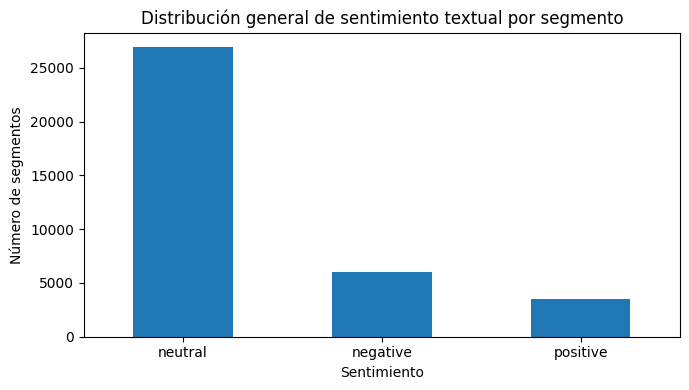

In [12]:
# ============================================================
# CELDA 12 - DISTRIBUCIÓN GENERAL DE SENTIMIENTO
# ============================================================

sentiment_distribution = (
    df_sent["sentiment_label"]
    .value_counts(dropna=False)
    .rename_axis("sentiment_label")
    .reset_index(name="n_segments")
)

sentiment_distribution["percentage"] = (
    sentiment_distribution["n_segments"] / len(df_sent) * 100
).round(2)

display(sentiment_distribution)

plt.figure(figsize=(7, 4))
df_sent["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Distribución general de sentimiento textual por segmento")
plt.xlabel("Sentimiento")
plt.ylabel("Número de segmentos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentiment_distribution_segments.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# ============================================================
# CELDA 13 - SENTIMIENTO AGREGADO POR LLAMADA
# ============================================================

def classify_avg_sentiment(x):
    if pd.isna(x):
        return "unknown"
    if x <= -0.25:
        return "negative"
    if x >= 0.25:
        return "positive"
    return "neutral"

call_sentiment = (
    df_sent
    .groupby(["audio_file", "audio_stem"], dropna=False)
    .agg(
        n_segments=("text_whisper", "count"),
        total_words=("n_words", "sum"),
        total_duration=("duration", "sum") if "duration" in df_sent.columns else ("n_words", "count"),
        avg_sentiment=("sentiment_numeric", "mean"),
        avg_confidence=("sentiment_score", "mean"),
        pct_negative=("sentiment_label", lambda x: (x == "negative").mean()),
        pct_neutral=("sentiment_label", lambda x: (x == "neutral").mean()),
        pct_positive=("sentiment_label", lambda x: (x == "positive").mean()),
        n_client_segments=("role_proxy", lambda x: (x == "CLIENT").sum()),
        n_agent_segments=("role_proxy", lambda x: (x == "AGENT").sum()),
    )
    .reset_index()
)

call_sentiment["call_sentiment_label"] = call_sentiment["avg_sentiment"].apply(classify_avg_sentiment)

call_sentiment.to_csv(CALL_SENTIMENT_CSV, index=False)

print("Call-level sentiment guardado en:", CALL_SENTIMENT_CSV)
display(call_sentiment.head())

Call-level sentiment guardado en: /home/jupyter/TFM_ProcesadoDeAudios/data/sentiment_outputs/call_level_sentiment_textual.csv


,audio_file,audio_stem,n_segments,total_words,total_duration,avg_sentiment,avg_confidence,pct_negative,pct_neutral,pct_positive,n_client_segments,n_agent_segments,call_sentiment_label
0,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,36,482,146.390625,-0.055556,0.703853,0.194444,0.666667,0.138889,17,19,neutral
1,raw_9154117551220006851_clean.wav,raw_9154117551220006851_clean,37,406,129.667500,-0.054054,0.690973,0.081081,0.891892,0.027027,15,22,neutral
2,raw_9154127337680006851_clean.wav,raw_9154127337680006851_clean,27,315,120.015000,0.037037,0.762638,0.037037,0.888889,0.074074,0,0,neutral
3,raw_9154142438160016851_clean.wav,raw_9154142438160016851_clean,45,824,232.858125,-0.088889,0.748466,0.177778,0.733333,0.088889,0,0,neutral
4,raw_9154152155960016851_clean.wav,raw_9154152155960016851_clean,33,505,132.721875,-0.060606,0.774458,0.181818,0.696970,0.121212,16,17,neutral


In [14]:
# ============================================================
# CELDA 14 - SENTIMIENTO AGREGADO POR ROL Y LLAMADA
# ============================================================

df_role = df_sent[df_sent["role_proxy"].isin(["AGENT", "CLIENT"])].copy()

call_role_sentiment = (
    df_role
    .groupby(["audio_file", "audio_stem", "role_proxy"], dropna=False)
    .agg(
        n_segments=("text_whisper", "count"),
        total_words=("n_words", "sum"),
        total_duration=("duration", "sum") if "duration" in df_role.columns else ("n_words", "count"),
        avg_sentiment=("sentiment_numeric", "mean"),
        avg_confidence=("sentiment_score", "mean"),
        pct_negative=("sentiment_label", lambda x: (x == "negative").mean()),
        pct_neutral=("sentiment_label", lambda x: (x == "neutral").mean()),
        pct_positive=("sentiment_label", lambda x: (x == "positive").mean()),
    )
    .reset_index()
)

call_role_sentiment["role_sentiment_label"] = call_role_sentiment["avg_sentiment"].apply(classify_avg_sentiment)
call_role_sentiment.to_csv(CALL_ROLE_SENTIMENT_CSV, index=False)

role_global_sentiment = (
    df_role
    .groupby("role_proxy", dropna=False)
    .agg(
        n_segments=("text_whisper", "count"),
        n_audios=("audio_file", "nunique"),
        total_words=("n_words", "sum"),
        avg_sentiment=("sentiment_numeric", "mean"),
        avg_confidence=("sentiment_score", "mean"),
        pct_negative=("sentiment_label", lambda x: (x == "negative").mean()),
        pct_neutral=("sentiment_label", lambda x: (x == "neutral").mean()),
        pct_positive=("sentiment_label", lambda x: (x == "positive").mean()),
    )
    .reset_index()
)

role_global_sentiment.to_csv(ROLE_SENTIMENT_CSV, index=False)

print("Call-role sentiment guardado en:", CALL_ROLE_SENTIMENT_CSV)
print("Role-level sentiment guardado en:", ROLE_SENTIMENT_CSV)

display(role_global_sentiment)
display(call_role_sentiment.head())

Call-role sentiment guardado en: /home/jupyter/TFM_ProcesadoDeAudios/data/sentiment_outputs/call_role_level_sentiment_textual.csv
Role-level sentiment guardado en: /home/jupyter/TFM_ProcesadoDeAudios/data/sentiment_outputs/role_level_sentiment_textual.csv


,role_proxy,n_segments,n_audios,total_words,avg_sentiment,avg_confidence,pct_negative,pct_neutral,pct_positive
0,AGENT,19326,1166,307840,-0.034047,0.746005,0.122891,0.788265,0.088844
1,CLIENT,16727,1166,198392,-0.110958,0.716673,0.214922,0.681114,0.103964


,audio_file,audio_stem,role_proxy,n_segments,total_words,total_duration,avg_sentiment,avg_confidence,pct_negative,pct_neutral,pct_positive,role_sentiment_label
0,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,AGENT,19,309,90.264375,-0.105263,0.727498,0.210526,0.684211,0.105263,neutral
1,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,CLIENT,17,173,56.126250,0.000000,0.677426,0.176471,0.647059,0.176471,neutral
2,raw_9154117551220006851_clean.wav,raw_9154117551220006851_clean,AGENT,22,288,93.133125,-0.045455,0.703457,0.090909,0.863636,0.045455,neutral
3,raw_9154117551220006851_clean.wav,raw_9154117551220006851_clean,CLIENT,15,118,36.534375,-0.066667,0.672662,0.066667,0.933333,0.000000,neutral
4,raw_9154152155960016851_clean.wav,raw_9154152155960016851_clean,AGENT,17,284,70.638750,-0.058824,0.777796,0.117647,0.823529,0.058824,neutral


In [15]:
# ============================================================
# CELDA 15 - SENTIMIENTO POR SPEAKER FINAL
# ============================================================

speaker_sentiment = (
    df_sent
    .groupby(["audio_file", "audio_stem", "speaker_final"], dropna=False)
    .agg(
        n_segments=("text_whisper", "count"),
        total_words=("n_words", "sum"),
        avg_sentiment=("sentiment_numeric", "mean"),
        avg_confidence=("sentiment_score", "mean"),
        pct_negative=("sentiment_label", lambda x: (x == "negative").mean()),
        pct_neutral=("sentiment_label", lambda x: (x == "neutral").mean()),
        pct_positive=("sentiment_label", lambda x: (x == "positive").mean()),
        dominant_role=("role_proxy", lambda x: x.value_counts().index[0] if len(x.value_counts()) else "UNKNOWN"),
    )
    .reset_index()
)

speaker_sentiment.to_csv(SPEAKER_SENTIMENT_CSV, index=False)
print("Speaker-level sentiment guardado en:", SPEAKER_SENTIMENT_CSV)
display(speaker_sentiment.head())

Speaker-level sentiment guardado en: /home/jupyter/TFM_ProcesadoDeAudios/data/sentiment_outputs/speaker_level_sentiment_textual.csv


,audio_file,audio_stem,speaker_final,n_segments,total_words,avg_sentiment,avg_confidence,pct_negative,pct_neutral,pct_positive,dominant_role
0,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,SPEAKER_00,17,173,0.000000,0.677426,0.176471,0.647059,0.176471,CLIENT
1,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,SPEAKER_01,19,309,-0.105263,0.727498,0.210526,0.684211,0.105263,AGENT
2,raw_9154117551220006851_clean.wav,raw_9154117551220006851_clean,SPEAKER_00,22,288,-0.045455,0.703457,0.090909,0.863636,0.045455,AGENT
3,raw_9154117551220006851_clean.wav,raw_9154117551220006851_clean,SPEAKER_01,15,118,-0.066667,0.672662,0.066667,0.933333,0.000000,CLIENT
4,raw_9154127337680006851_clean.wav,raw_9154127337680006851_clean,SPEAKER_00,12,192,0.000000,0.832237,0.000000,1.000000,0.000000,UNKNOWN


Temporal sentiment guardado en: /home/jupyter/TFM_ProcesadoDeAudios/data/sentiment_outputs/temporal_sentiment_textual.csv


,call_phase,role_proxy,n_segments,n_audios,avg_sentiment,pct_negative,pct_positive
0,inicio,AGENT,6477,1143,-0.056199,0.109927,0.053729
1,inicio,CLIENT,6285,1149,-0.186953,0.240573,0.053620
2,inicio,UNKNOWN,138,14,-0.173913,0.224638,0.050725
3,mitad,AGENT,6331,1140,-0.099194,0.145317,0.046122
4,mitad,CLIENT,5171,1118,-0.172694,0.228389,0.055695
5,mitad,UNKNOWN,128,14,-0.226562,0.250000,0.023438
6,final,AGENT,6518,1142,0.051243,0.113992,0.165235
7,final,CLIENT,5271,1117,0.040220,0.171125,0.211345
8,final,UNKNOWN,134,15,-0.022388,0.179104,0.156716


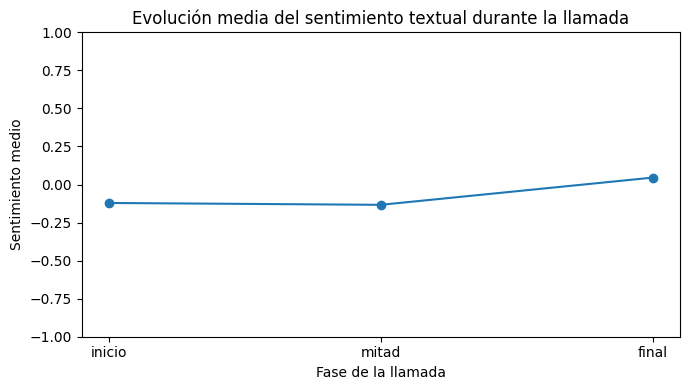

In [16]:
# ============================================================
# CELDA 16 - EVOLUCIÓN TEMPORAL POR FASE DE LLAMADA Y ROL
# ============================================================

df_temporal = df_sent.copy()

if {"start", "end"}.issubset(df_temporal.columns):
    call_max_end = (
        df_temporal
        .groupby("audio_file")["end"]
        .max()
        .rename("call_duration")
        .reset_index()
    )

    df_temporal = df_temporal.merge(call_max_end, on="audio_file", how="left")
    df_temporal["relative_position"] = pd.to_numeric(df_temporal["start"], errors="coerce") / df_temporal["call_duration"]

    def assign_call_phase(pos):
        if pd.isna(pos):
            return "unknown"
        if pos < 1/3:
            return "inicio"
        if pos < 2/3:
            return "mitad"
        return "final"

    df_temporal["call_phase"] = df_temporal["relative_position"].apply(assign_call_phase)
else:
    df_temporal["call_phase"] = "unknown"

# Agregado por fase global y rol.
temporal_sentiment = (
    df_temporal
    .groupby(["call_phase", "role_proxy"], dropna=False)
    .agg(
        n_segments=("text_whisper", "count"),
        n_audios=("audio_file", "nunique"),
        avg_sentiment=("sentiment_numeric", "mean"),
        pct_negative=("sentiment_label", lambda x: (x == "negative").mean()),
        pct_positive=("sentiment_label", lambda x: (x == "positive").mean()),
    )
    .reset_index()
)

phase_order = pd.CategoricalDtype(categories=["inicio", "mitad", "final", "unknown"], ordered=True)
temporal_sentiment["call_phase"] = temporal_sentiment["call_phase"].astype(phase_order)
temporal_sentiment = temporal_sentiment.sort_values(["call_phase", "role_proxy"]).reset_index(drop=True)

temporal_sentiment.to_csv(TEMPORAL_SENTIMENT_CSV, index=False)
print("Temporal sentiment guardado en:", TEMPORAL_SENTIMENT_CSV)
display(temporal_sentiment)

# Figura simple global por fase.
global_temporal = (
    df_temporal
    .groupby("call_phase", dropna=False)
    .agg(avg_sentiment=("sentiment_numeric", "mean"), n_segments=("text_whisper", "count"))
    .reset_index()
)
global_temporal["call_phase"] = global_temporal["call_phase"].astype(phase_order)
global_temporal = global_temporal.sort_values("call_phase")

plt.figure(figsize=(7, 4))
plt.plot(global_temporal["call_phase"].astype(str), global_temporal["avg_sentiment"], marker="o")
plt.title("Evolución media del sentimiento textual durante la llamada")
plt.xlabel("Fase de la llamada")
plt.ylabel("Sentimiento medio")
plt.ylim(-1, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sentiment_temporal_global.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# ============================================================
# CELDA 17 - LLAMADAS CON MAYOR CARGA NEGATIVA DEL CLIENTE
# ============================================================

client_negative_calls = (
    call_role_sentiment[call_role_sentiment["role_proxy"] == "CLIENT"]
    .sort_values(["avg_sentiment", "pct_negative"], ascending=[True, False])
    .head(20)
)

print("Top llamadas con mayor carga negativa del CLIENT:")
display(client_negative_calls)

# Ejemplo cualitativo: llamada más negativa del cliente.
if not client_negative_calls.empty:
    sample_audio = client_negative_calls.iloc[0]["audio_file"]
    print("Llamada seleccionada:", sample_audio)

    cols_review = [
        "interval_mmss", "speaker_final", "role_proxy", "text_whisper",
        "sentiment_label", "sentiment_score", "sentiment_numeric"
    ]
    cols_review = [c for c in cols_review if c in df_sent.columns]

    display(
        df_sent[df_sent["audio_file"] == sample_audio]
        .sort_values(["start", "end"] if {"start", "end"}.issubset(df_sent.columns) else ["sentiment_uid"])[cols_review]
        .head(80)
    )

Top llamadas con mayor carga negativa del CLIENT:


,audio_file,audio_stem,role_proxy,n_segments,total_words,total_duration,avg_sentiment,avg_confidence,pct_negative,pct_neutral,pct_positive,role_sentiment_label
65,raw_9154635155880006851_clean.wav,raw_9154635155880006851_clean,CLIENT,2,36,10.293750,-1.000000,0.871507,1.000000,0.000000,0.000000,negative
943,raw_bajas_9156520333980006851_clean.wav,raw_bajas_9156520333980006851_clean,CLIENT,2,21,4.404375,-1.000000,0.865851,1.000000,0.000000,0.000000,negative
1223,raw_bajas_9156786673410006851_clean.wav,raw_bajas_9156786673410006851_clean,CLIENT,12,176,47.570625,-0.833333,0.774935,0.833333,0.166667,0.000000,negative
2323,raw_bajas_9157452496450006851_clean.wav,raw_bajas_9157452496450006851_clean,CLIENT,6,335,86.906250,-0.833333,0.847570,0.833333,0.166667,0.000000,negative
17,raw_9154281641250016851_clean.wav,raw_9154281641250016851_clean,CLIENT,4,167,53.038125,-0.750000,0.722952,0.750000,0.250000,0.000000,negative
1175,raw_bajas_9156725216470006851_clean.wav,raw_bajas_9156725216470006851_clean,CLIENT,8,118,36.736875,-0.750000,0.769789,0.750000,0.250000,0.000000,negative
2159,raw_bajas_9157365394740006851_clean.wav,raw_bajas_9157365394740006851_clean,CLIENT,4,53,14.866875,-0.750000,0.751091,0.750000,0.250000,0.000000,negative
1789,raw_bajas_9157236405500006851_clean.wav,raw_bajas_9157236405500006851_clean,CLIENT,32,531,148.651875,-0.718750,0.815427,0.750000,0.218750,0.031250,negative
539,raw_bajas_9156182796590006851_clean.wav,raw_bajas_9156182796590006851_clean,CLIENT,7,49,14.596875,-0.714286,0.736996,0.714286,0.285714,0.000000,negative
587,raw_bajas_9156252092130006851_clean.wav,raw_bajas_9156252092130006851_clean,CLIENT,7,211,72.967500,-0.714286,0.722420,0.714286,0.285714,0.000000,negative


Llamada seleccionada: raw_9154635155880006851_clean.wav


,interval_mmss,speaker_final,role_proxy,text_whisper,sentiment_label,sentiment_score,sentiment_numeric
1359,00:00 - 00:03,SPEAKER_00,AGENT,"Hola, buenas tardes. Soy Tomás. Está hablando con su operador de fibra. ¿En qué puedo ayudarle?",neutral,0.821766,0
1360,00:04 - 00:12,SPEAKER_01,CLIENT,Es que estoy esperando al chico que tiene que venir y me han dicho a los dos y me tengo que ir y viene.,negative,0.820157,-1
1361,00:12 - 00:14,SPEAKER_00,AGENT,"Vale, un momento. Voy a intentar hablar con ellos.",neutral,0.732363,0
1362,00:15 - 00:18,SPEAKER_00,AGENT,"Un segundo. Voy para hablar con ello. No se retire, por favor.",neutral,0.679062,0
1363,00:21 - 00:26,SPEAKER_00,AGENT,"Hola, buena tarde. Soy tomás. Hola, muy buenos días.",positive,0.645568,1
1364,00:26 - 00:52,SPEAKER_00,AGENT,"Es que tengo un cliente que me ha llamado que era para ir ahora a las 12 en calle Bernardo. Ah, pues mira, justo a las 13. No, lo tengo que estar a las 14. ...",neutral,0.797655,0
1365,00:56 - 00:59,SPEAKER_00,AGENT,El número es el que acaba en 9...,neutral,0.775980,0
1366,01:00 - 01:05,SPEAKER_00,AGENT,"Sí, 111. No, 91. Sí, el 112 del teléfono, sí. Vale, le llamo ahora mismo, ¿vale?",neutral,0.807306,0
1367,01:06 - 01:08,SPEAKER_00,AGENT,"Vale, muchas gracias. Vale, muy bien. Chao, chao.",positive,0.742217,1
1368,01:10 - 01:13,SPEAKER_00,AGENT,Me ha dicho que el técnico le va a llamar ahora. Que iba para allá.,neutral,0.570861,0


In [18]:
# ============================================================
# CELDA 18 - RESUMEN FINAL PARA MEMORIA
# ============================================================

summary_rows = []

summary_rows.append({"metric": "audios_base", "value": df_base["audio_file"].nunique()})
summary_rows.append({"metric": "segments_base", "value": len(df_base)})
summary_rows.append({"metric": "segments_with_text", "value": int((df_base["n_chars"] > 0).sum())})
summary_rows.append({"metric": "segments_analyzed_sentiment", "value": len(df_sent)})
summary_rows.append({"metric": "audios_analyzed_sentiment", "value": df_sent["audio_file"].nunique()})
summary_rows.append({"metric": "segments_with_role_proxy", "value": int(df_sent["role_proxy"].isin(["AGENT", "CLIENT"]).sum())})
summary_rows.append({"metric": "pct_negative_segments", "value": round((df_sent["sentiment_label"] == "negative").mean() * 100, 2)})
summary_rows.append({"metric": "pct_neutral_segments", "value": round((df_sent["sentiment_label"] == "neutral").mean() * 100, 2)})
summary_rows.append({"metric": "pct_positive_segments", "value": round((df_sent["sentiment_label"] == "positive").mean() * 100, 2)})
summary_rows.append({"metric": "avg_sentiment_global", "value": round(df_sent["sentiment_numeric"].mean(), 4)})
summary_rows.append({"metric": "negative_calls", "value": int((call_sentiment["call_sentiment_label"] == "negative").sum())})
summary_rows.append({"metric": "neutral_calls", "value": int((call_sentiment["call_sentiment_label"] == "neutral").sum())})
summary_rows.append({"metric": "positive_calls", "value": int((call_sentiment["call_sentiment_label"] == "positive").sum())})

# Métricas por rol para memoria.
for _, row in role_global_sentiment.iterrows():
    role = row["role_proxy"]
    summary_rows.append({"metric": f"{role}_avg_sentiment", "value": round(row["avg_sentiment"], 4)})
    summary_rows.append({"metric": f"{role}_pct_negative", "value": round(row["pct_negative"] * 100, 2)})
    summary_rows.append({"metric": f"{role}_n_segments", "value": int(row["n_segments"])} )

summary_for_memory = pd.DataFrame(summary_rows)
summary_for_memory.to_csv(SENTIMENT_SUMMARY_CSV, index=False)

print("Resumen final guardado en:")
print(SENTIMENT_SUMMARY_CSV)

display(summary_for_memory)

Resumen final guardado en:
/home/jupyter/TFM_ProcesadoDeAudios/data/sentiment_outputs/sentiment_textual_summary_for_memory.csv


,metric,value
0,audios_base,1181.0000
1,segments_base,40352.0000
2,segments_with_text,38872.0000
3,segments_analyzed_sentiment,36453.0000
4,audios_analyzed_sentiment,1181.0000
5,segments_with_role_proxy,36053.0000
6,pct_negative_segments,16.6200
7,pct_neutral_segments,73.8200
8,pct_positive_segments,9.5700
9,avg_sentiment_global,-0.0705


## Nota metodológica

Este notebook calcula sentimiento **a partir del texto Whisper**. Por tanto, evalúa el contenido semántico transcrito, no el tono vocal directamente.  
Para mantener la línea del proyecto orientada a voz, este resultado debe interpretarse como una capa complementaria a los módulos acústicos: diarización, reetiquetado, huella vocal y, si se incorpora después, análisis prosódico sin transcripción.